In [2]:
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

base_path = Path(r"C:\Users\garcias\Downloads\results_learning_m_reg_v3\learning_m_reg_v3")

# Experiment parameters
SEEDS = ["seed_0", "seed_1"]
HIDDEN_SIZE = 64
SAMPLE_SIZE = 50
REG_LOGITS_LRS = [0.0001, 0.005, 0.001]

In [3]:
def load_all_experiments():
    """Load all experiment metadata into a DataFrame, parsing params from directory names."""
    records = []
    for seed_dir in sorted(base_path.glob("seed_*")):
        if not seed_dir.is_dir():
            continue
        for exp_dir in sorted(seed_dir.iterdir()):
            if not exp_dir.is_dir():
                continue
            match = re.match(
                r'p(\d+)_n(\d+)_h(\d+)_s(\d+)_M_reg(\d+)_rlr([\d.]+)',
                exp_dir.name
            )
            if not match:
                continue

            metadata_path = exp_dir / "metadata.json"
            if not metadata_path.exists():
                continue
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)

            records.append({
                'seed': seed_dir.name,
                'num_params': int(match.group(1)),
                'nonlinear_units': int(match.group(2)),
                'hidden_size': int(match.group(3)),
                'sample_size': int(match.group(4)),
                'M_reg': int(match.group(5)),
                'reg_logits_lr': float(match.group(6)),
                'best_test_loss': metadata.get('best_test_loss', np.nan),
                'best_avg_test_accuracy': metadata.get('best_avg_test_accuracy', np.nan),
                'exp_dir': str(exp_dir),
            })

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} experiments across {df['seed'].nunique()} seeds")
    print(f"  num_params:      {sorted(df['num_params'].unique())}")
    print(f"  nonlinear_units: {sorted(df['nonlinear_units'].unique())}")
    print(f"  M_reg:           {sorted(df['M_reg'].unique())}")
    print(f"  reg_logits_lr:   {sorted(df['reg_logits_lr'].unique())}")
    return df

df = load_all_experiments()

Loaded 48 experiments across 2 seeds
  num_params:      [np.int64(4), np.int64(8)]
  nonlinear_units: [np.int64(0), np.int64(2)]
  M_reg:           [np.int64(16), np.int64(32)]
  reg_logits_lr:   [np.float64(0.0001), np.float64(0.001), np.float64(0.005)]


# Per-Task Loss at Best Epoch

One heatmap per `reg_logits_lr`. Rows = tasks, columns = `(nonlinear_units, M_reg)`. Fixed `num_params=4`.

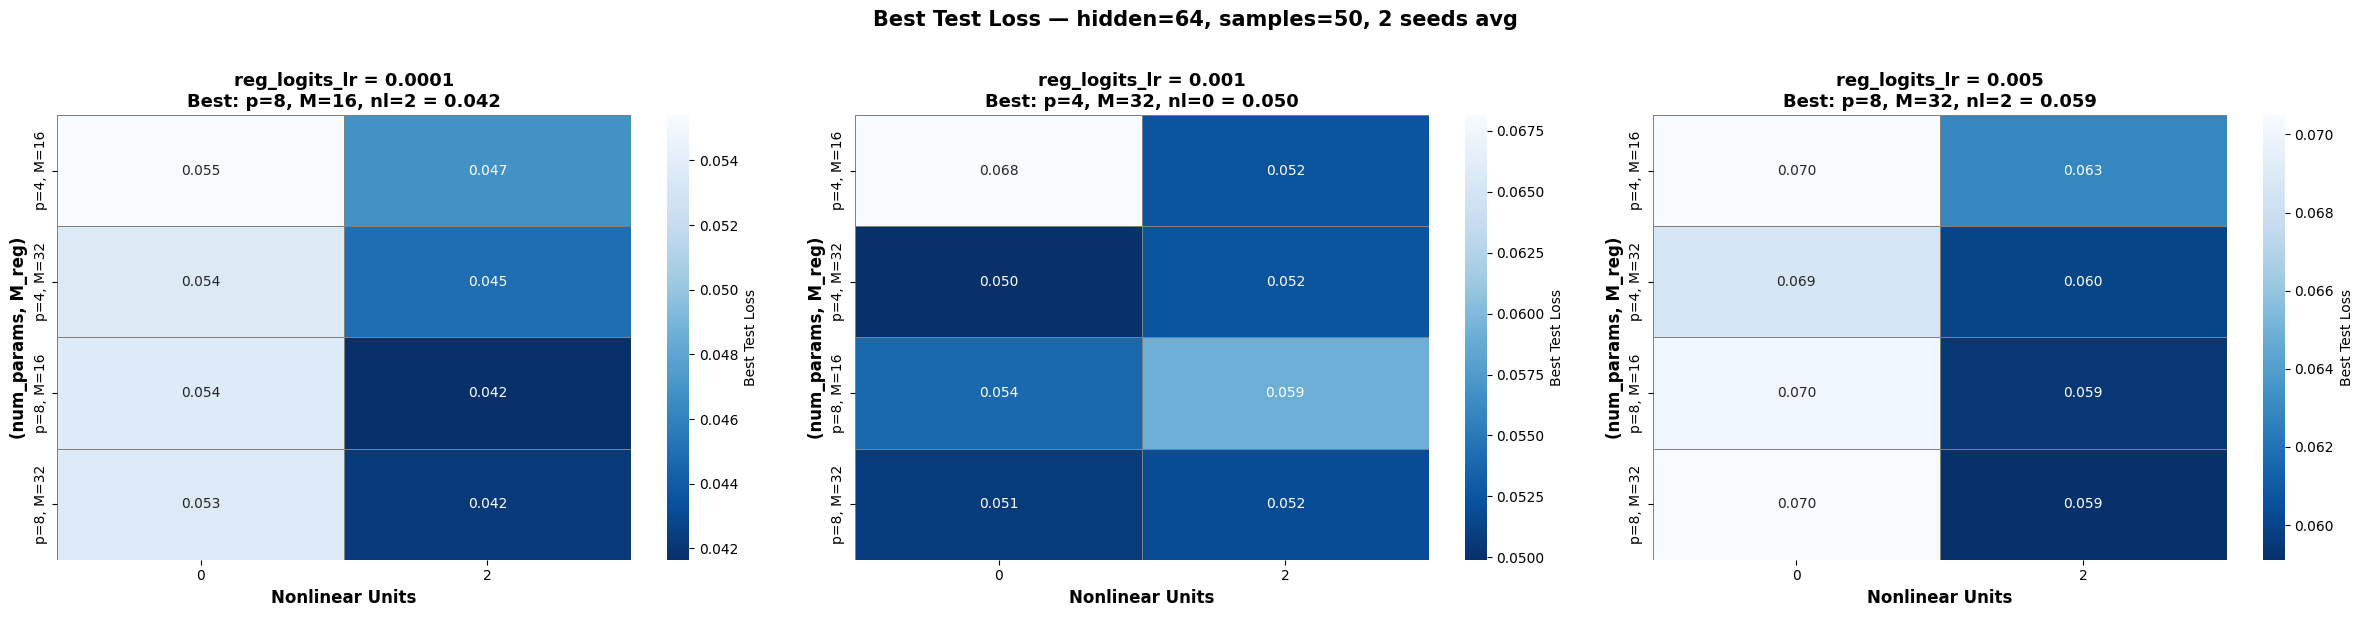

In [4]:
def create_best_loss_heatmaps_by_lr(df):
    """One heatmap per reg_logits_lr: rows = (num_params, M_reg), cols = nonlinear_units."""
    lr_values = sorted(df['reg_logits_lr'].unique())
    n_lr = len(lr_values)

    fig, axes = plt.subplots(1, n_lr, figsize=(8 * n_lr, 6))
    if n_lr == 1:
        axes = [axes]

    for ax, lr in zip(axes, lr_values):
        sub = df[df['reg_logits_lr'] == lr]

        # Create composite row index
        sub = sub.copy()
        sub['row_label'] = 'p=' + sub['num_params'].astype(str) + ', M=' + sub['M_reg'].astype(str)

        heatmap = sub.pivot_table(
            index='row_label',
            columns='nonlinear_units',
            values='best_test_loss',
            aggfunc='mean'
        ).sort_index(axis=0).sort_index(axis=1)

        min_idx = heatmap.stack().idxmin()
        min_row, min_nl = min_idx
        min_loss = heatmap.loc[min_row, min_nl]

        sns.heatmap(heatmap, annot=True, fmt='.3f', cmap='Blues_r',
                    cbar_kws={'label': 'Best Test Loss'},
                    linewidths=0.5, linecolor='gray', ax=ax)
        ax.set_xlabel('Nonlinear Units', fontsize=12, fontweight='bold')
        ax.set_ylabel('(num_params, M_reg)', fontsize=12, fontweight='bold')
        ax.set_title(f'reg_logits_lr = {lr}\nBest: {min_row}, nl={min_nl} = {min_loss:.3f}',
                     fontsize=13, fontweight='bold')

    plt.suptitle(f'Best Test Loss — hidden={HIDDEN_SIZE}, samples={SAMPLE_SIZE}, {df["seed"].nunique()} seeds avg',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

create_best_loss_heatmaps_by_lr(df)

# Best Avg Test Accuracy Heatmaps

Same layout — one heatmap per `reg_logits_lr`.

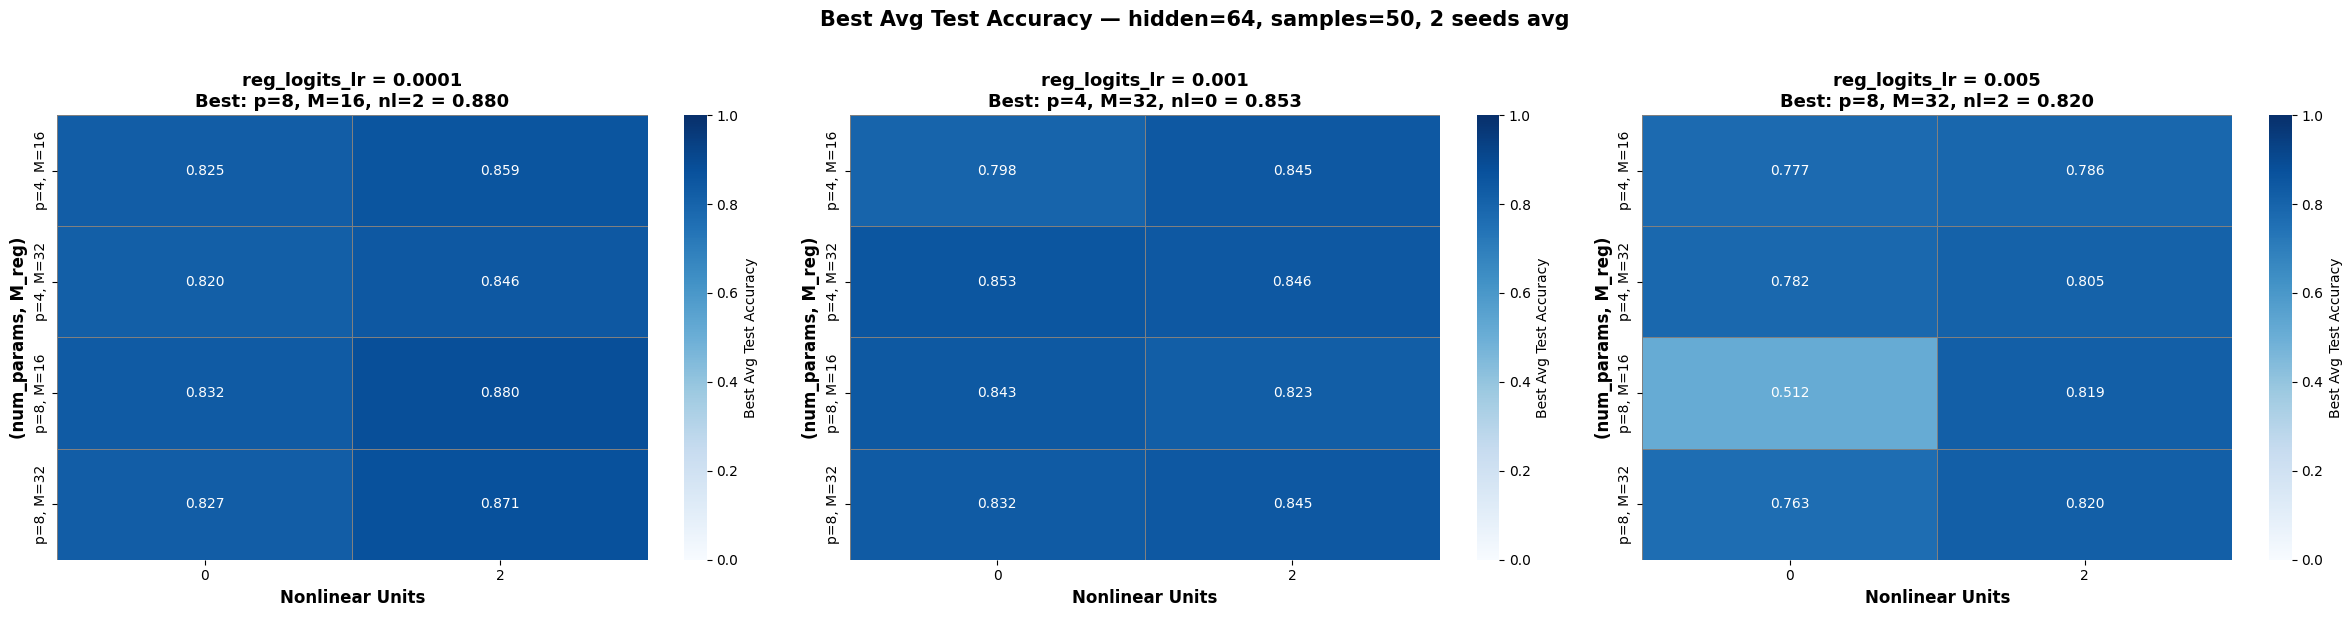

In [8]:
def create_best_accuracy_heatmaps_by_lr(df):
    """One heatmap per reg_logits_lr: rows = (num_params, M_reg), cols = nonlinear_units."""
    lr_values = sorted(df['reg_logits_lr'].unique())
    n_lr = len(lr_values)

    fig, axes = plt.subplots(1, n_lr, figsize=(8 * n_lr, 6))
    if n_lr == 1:
        axes = [axes]

    for ax, lr in zip(axes, lr_values):
        sub = df[df['reg_logits_lr'] == lr].copy()
        sub['row_label'] = 'p=' + sub['num_params'].astype(str) + ', M=' + sub['M_reg'].astype(str)

        heatmap = sub.pivot_table(
            index='row_label',
            columns='nonlinear_units',
            values='best_avg_test_accuracy',
            aggfunc='mean'
        ).sort_index(axis=0).sort_index(axis=1)

        max_idx = heatmap.stack().idxmax()
        max_row, max_nl = max_idx
        max_acc = heatmap.loc[max_row, max_nl]

        sns.heatmap(heatmap, annot=True, fmt='.3f', cmap='Blues',
                    cbar_kws={'label': 'Best Avg Test Accuracy'},
                    linewidths=0.5, linecolor='gray', ax=ax,
                    vmin=0.0, vmax=1.0)
        ax.set_xlabel('Nonlinear Units', fontsize=12, fontweight='bold')
        ax.set_ylabel('(num_params, M_reg)', fontsize=12, fontweight='bold')
        ax.set_title(f'reg_logits_lr = {lr}\nBest: {max_row}, nl={max_nl} = {max_acc:.3f}',
                     fontsize=13, fontweight='bold')

    plt.suptitle(f'Best Avg Test Accuracy — hidden={HIDDEN_SIZE}, samples={SAMPLE_SIZE}, {df["seed"].nunique()} seeds avg',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

create_best_accuracy_heatmaps_by_lr(df)

# Per-Task Accuracy at Best Epoch

One heatmap per `reg_logits_lr`. Rows = tasks, columns = `(nonlinear_units, M_reg)`. Fixed `num_params=4`.

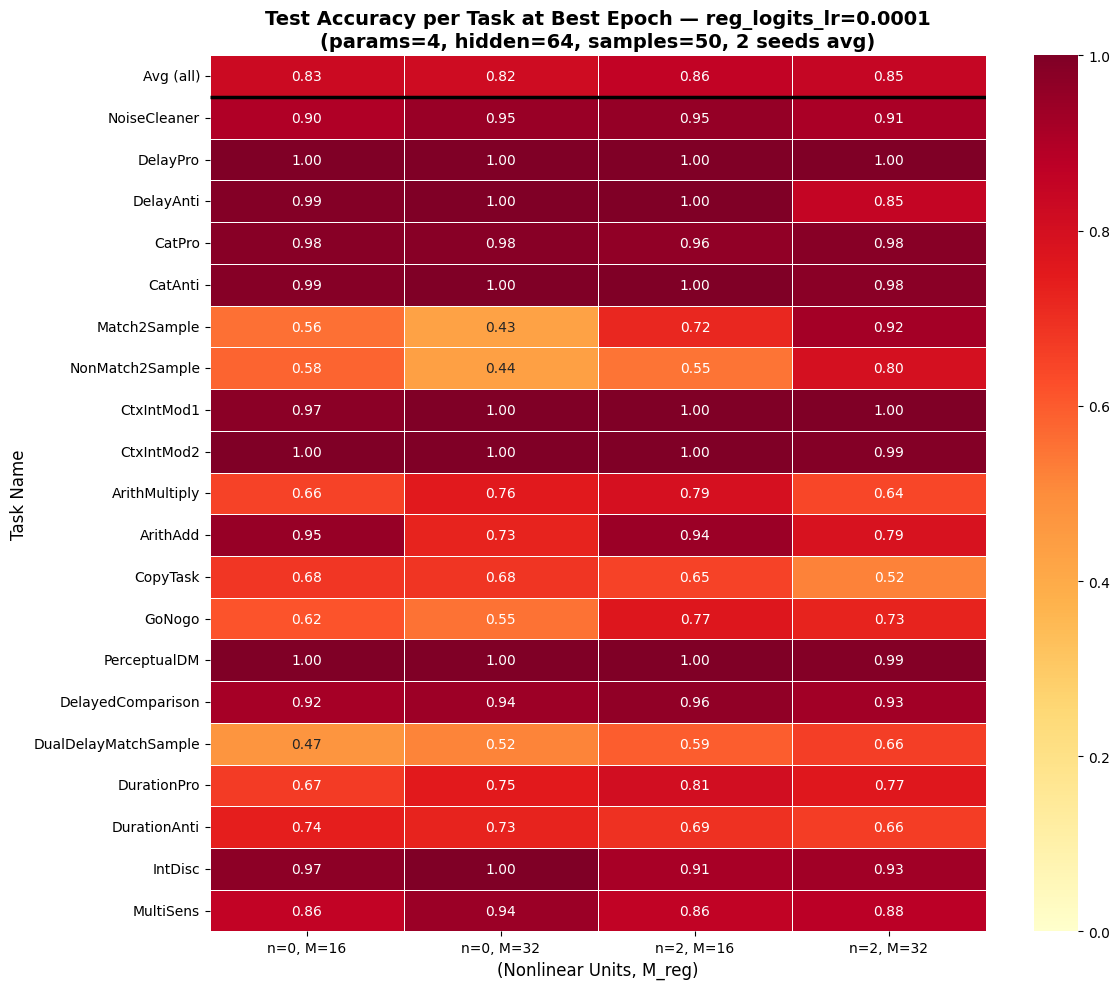

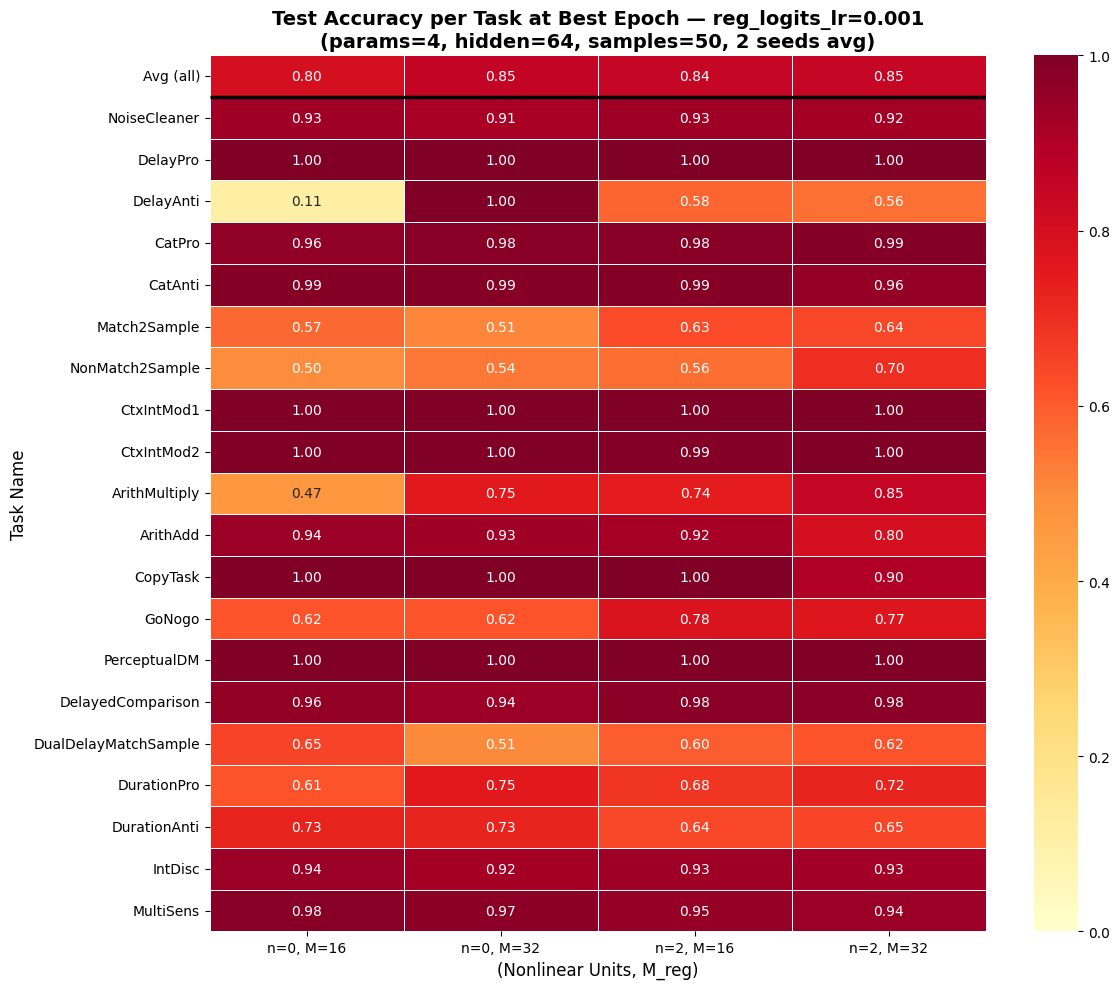

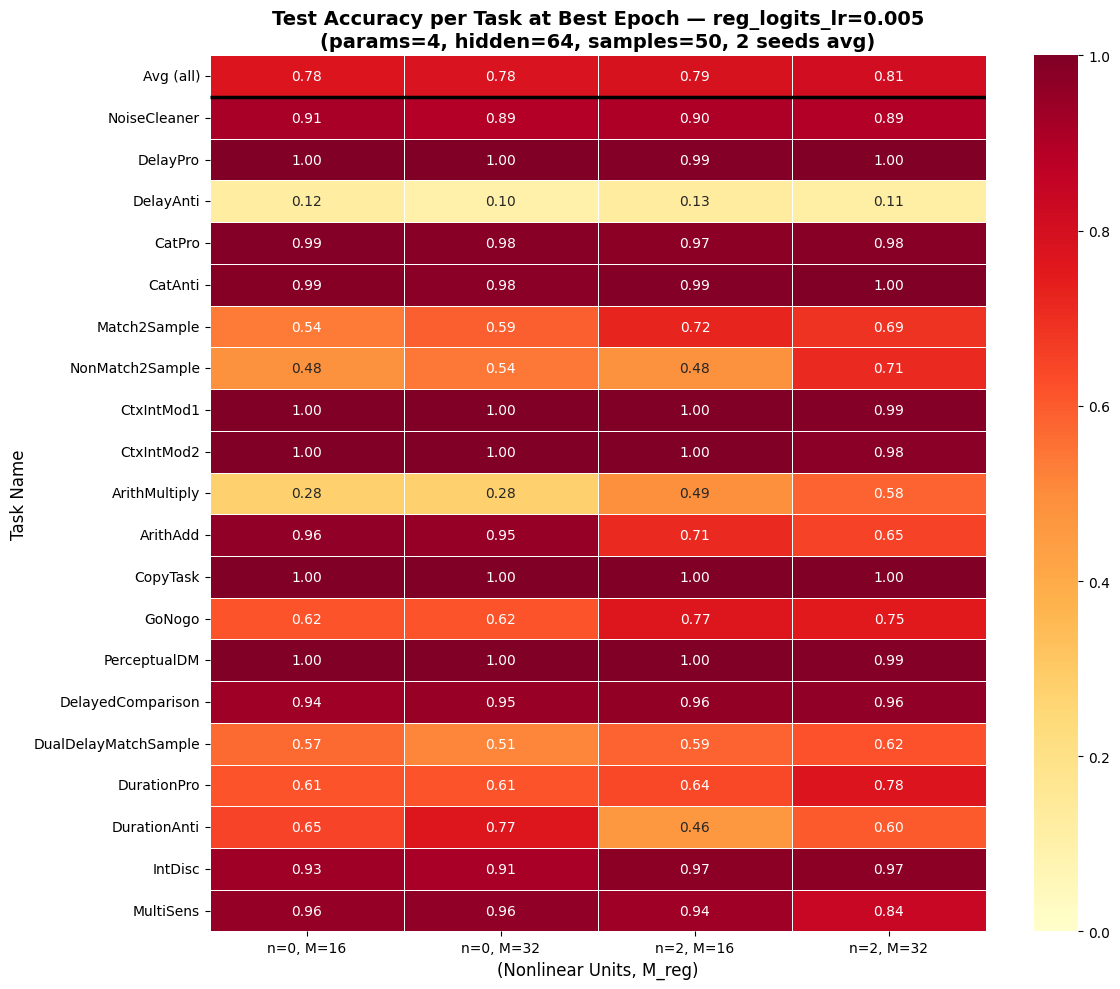

In [9]:
def plot_per_task_best_epoch_by_lr(df, fixed_params=4):
    """Per-task accuracy heatmap at best epoch, one figure per reg_logits_lr."""
    lr_values = sorted(df['reg_logits_lr'].unique())

    for lr in lr_values:
        sub = df[(df['reg_logits_lr'] == lr) & (df['num_params'] == fixed_params)]
        if sub.empty:
            print(f"No data for lr={lr}, params={fixed_params}")
            continue

        all_accuracies = {}  # task_name -> {col_label -> [acc_per_seed]}

        for _, row in sub.iterrows():
            exp_dir = Path(row['exp_dir'])
            nl_val = row['nonlinear_units']
            m_reg = row['M_reg']
            col_label = f"n={nl_val}, M={m_reg}"

            data = np.load(exp_dir / "results.npz", allow_pickle=True)
            with open(exp_dir / "metadata.json", 'r') as f:
                metadata = json.load(f)

            # Use argmin to match training code exactly (avoids float precision issues with JSON)
            best_idx = np.argmin(data['test_loss_history'])
            raw = data["test_task_accuracies"].item()
            task_names = metadata["task_names"]

            for k, v in raw.items():
                task_name = task_names[k]
                if task_name not in all_accuracies:
                    all_accuracies[task_name] = {}
                if col_label not in all_accuracies[task_name]:
                    all_accuracies[task_name][col_label] = []
                all_accuracies[task_name][col_label].append(v[best_idx])

        col_labels = sorted(set(
            cl for task_accs in all_accuracies.values() for cl in task_accs
        ))
        task_names_ordered = list(all_accuracies.keys())

        heatmap_data = pd.DataFrame(
            index=task_names_ordered, columns=col_labels, dtype=float
        )
        for task in task_names_ordered:
            for cl in col_labels:
                vals = all_accuracies[task].get(cl, [])
                heatmap_data.loc[task, cl] = np.mean(vals) if vals else np.nan

        avg_all = heatmap_data.astype(float).mean(axis=0)
        heatmap_data.loc["Avg (all)"] = avg_all
        heatmap_data = heatmap_data.loc[["Avg (all)"] + task_names_ordered]

        plt.figure(figsize=(max(12, len(col_labels) * 2.5), 10))
        ax = sns.heatmap(
            heatmap_data.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
            vmin=0, vmax=1, linewidths=0.5
        )
        ax.hlines([1], *ax.get_xlim(), colors='black', linewidths=2.5)
        plt.xlabel("(Nonlinear Units, M_reg)", fontsize=12)
        plt.ylabel("Task Name", fontsize=12)
        plt.title(
            f"Test Accuracy per Task at Best Epoch — reg_logits_lr={lr}\n"
            f"(params={fixed_params}, hidden={HIDDEN_SIZE}, samples={SAMPLE_SIZE}, "
            f"{sub['seed'].nunique()} seeds avg)",
            fontsize=14, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()

plot_per_task_best_epoch_by_lr(df, fixed_params=4)

# Per-Task Accuracy — fixed `num_params=8`

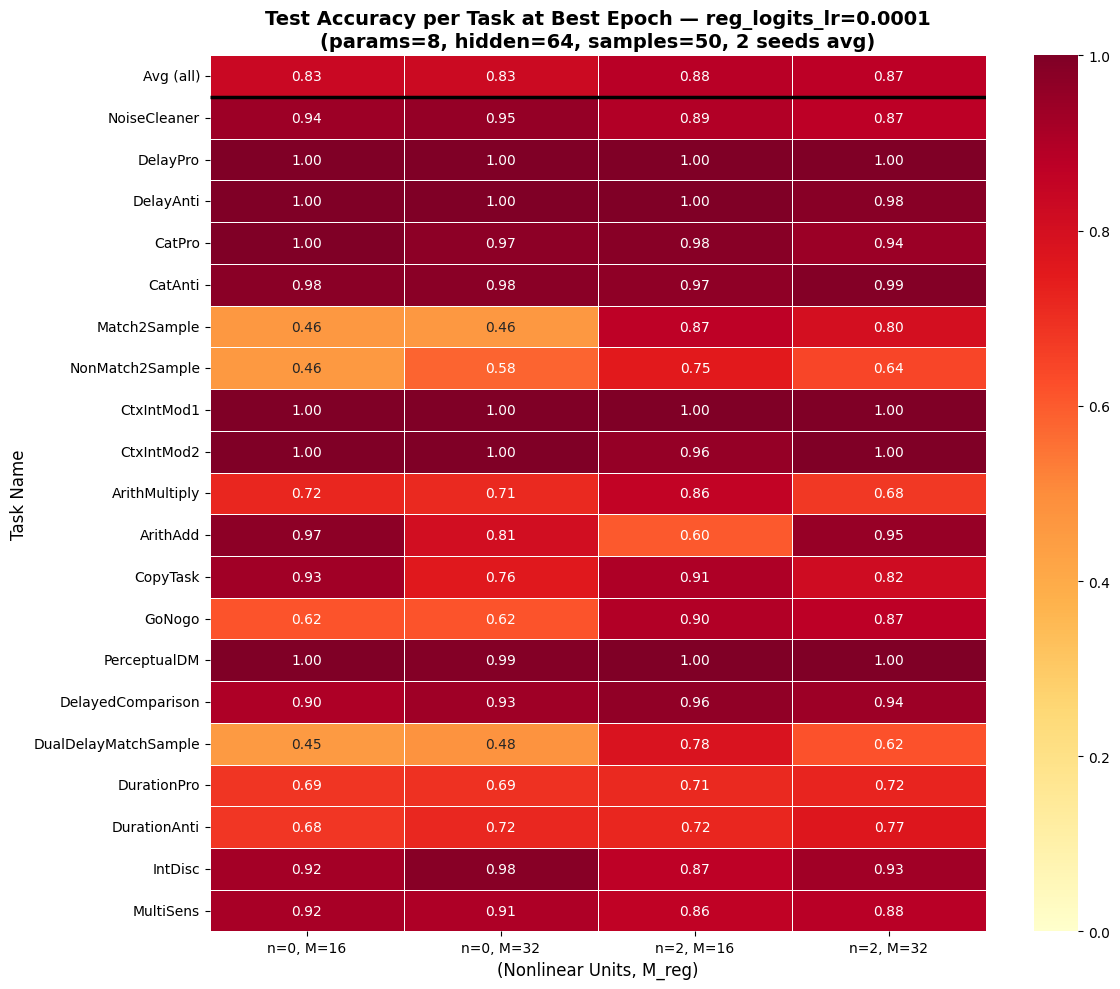

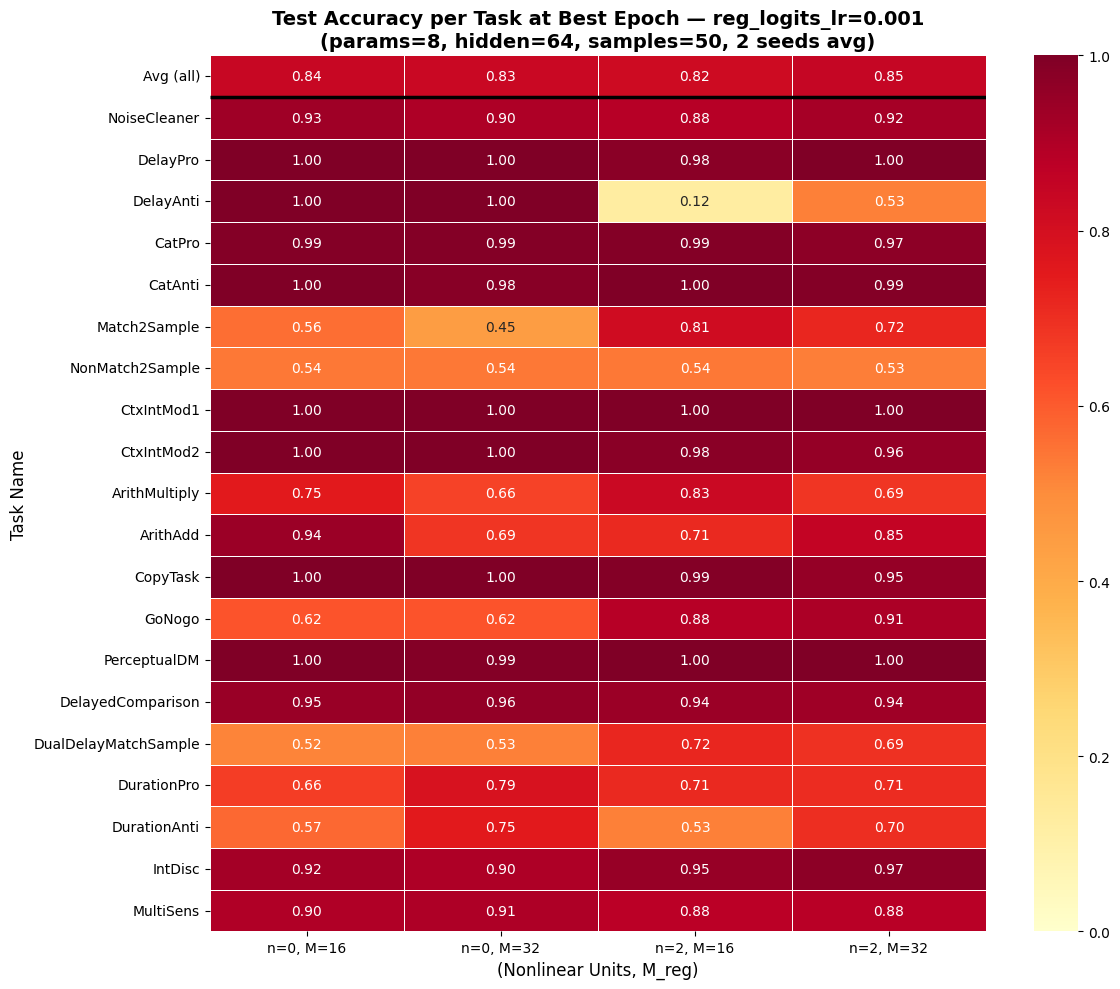

IndexError: index 0 is out of bounds for axis 0 with size 0

In [7]:
plot_per_task_best_epoch_by_lr(df, fixed_params=8)

# Per-Seed Accuracy — reg_logits_lr=0.0001

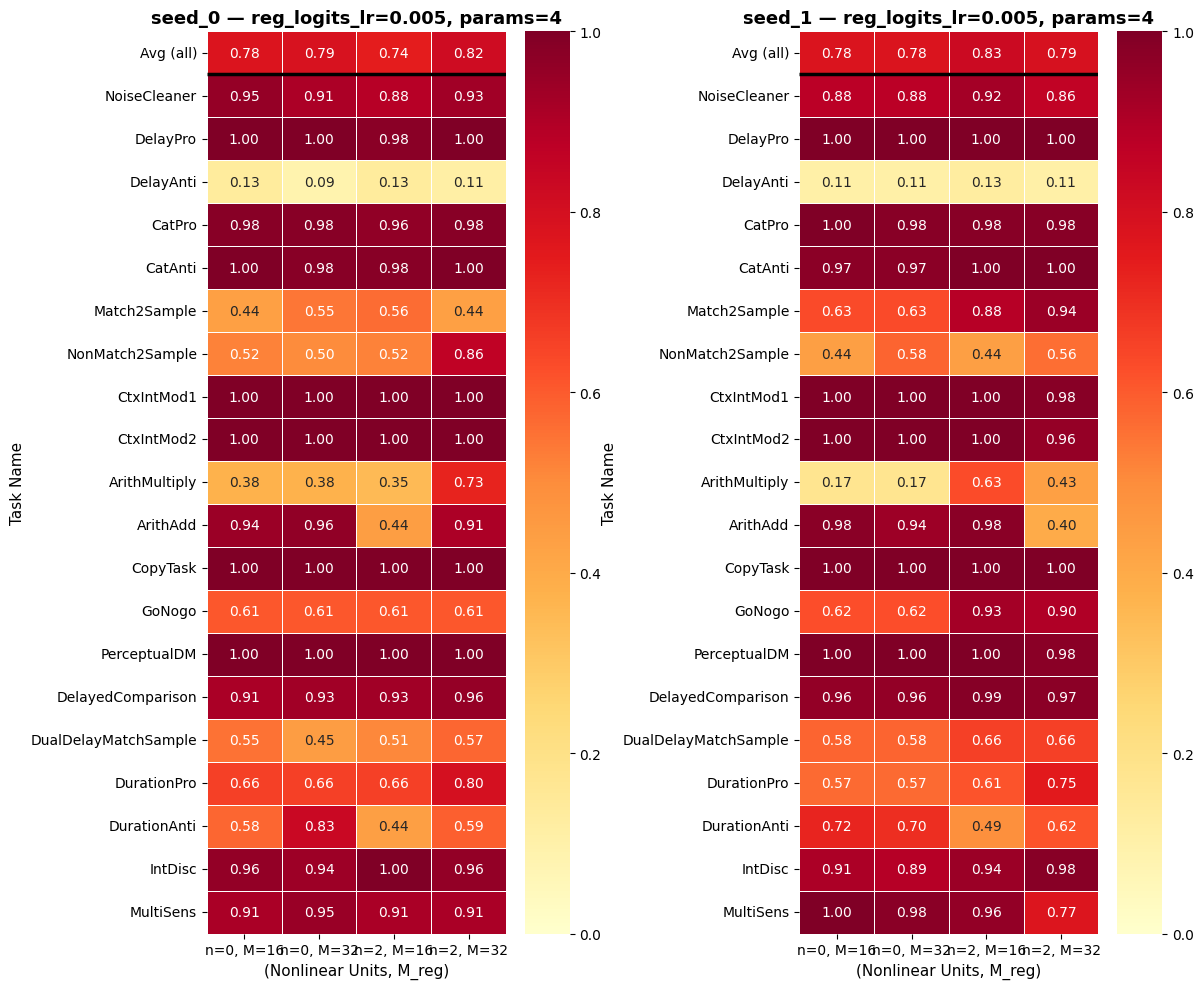

In [34]:
def plot_per_task_per_seed(df, fixed_lr=0.005, fixed_params=4):
    """One per-task accuracy heatmap per seed, for a fixed reg_logits_lr."""
    sub = df[(df['reg_logits_lr'] == fixed_lr) & (df['num_params'] == fixed_params)]
    seeds = sorted(sub['seed'].unique())

    fig, axes = plt.subplots(1, len(seeds), figsize=(max(12, 6 * len(seeds)), 10))
    if len(seeds) == 1:
        axes = [axes]

    for ax, seed in zip(axes, seeds):
        seed_sub = sub[sub['seed'] == seed]
        task_accs = {}

        for _, row in seed_sub.iterrows():
            exp_dir = Path(row['exp_dir'])
            nl_val = row['nonlinear_units']
            m_reg = row['M_reg']
            col_label = f"n={nl_val}, M={m_reg}"

            data = np.load(exp_dir / "results.npz", allow_pickle=True)
            meta = json.load(open(exp_dir / "metadata.json"))
            best_idx = np.argmin(data['test_loss_history'])
            raw = data["test_task_accuracies"].item()
            task_names = meta["task_names"]

            for k, v in raw.items():
                task_name = task_names[k]
                if task_name not in task_accs:
                    task_accs[task_name] = {}
                task_accs[task_name][col_label] = v[best_idx]

        col_labels = sorted(set(cl for d in task_accs.values() for cl in d))
        task_names_ordered = list(task_accs.keys())

        heatmap_data = pd.DataFrame(index=task_names_ordered, columns=col_labels, dtype=float)
        for task in task_names_ordered:
            for cl in col_labels:
                heatmap_data.loc[task, cl] = task_accs[task].get(cl, np.nan)

        avg_all = heatmap_data.astype(float).mean(axis=0)
        heatmap_data.loc["Avg (all)"] = avg_all
        heatmap_data = heatmap_data.loc[["Avg (all)"] + task_names_ordered]

        sns.heatmap(heatmap_data.astype(float), annot=True, fmt=".2f", cmap="YlOrRd",
                    vmin=0, vmax=1, linewidths=0.5, ax=ax)
        # Draw line below Avg row
        ax.hlines([1], *ax.get_xlim(), colors='black', linewidths=2.5)
        ax.set_xlabel("(Nonlinear Units, M_reg)", fontsize=11)
        ax.set_ylabel("Task Name", fontsize=11)
        ax.set_title(f"{seed} — reg_logits_lr={fixed_lr}, params={fixed_params}",
                     fontsize=13, fontweight='bold')

    plt.tight_layout()
    plt.show()

plot_per_task_per_seed(df, fixed_lr=0.005, fixed_params=4)

# Eigenvalue Spectra — seed_0, n=0, M_reg=16

In [36]:
import torch

# Load model for seed_0, p=4, n=0, M_reg=16, rlr=0.0001
exp_dir = base_path / "seed_0" / "p4_n2_h64_s50_M_reg32_rlr0.005"
state_dict = torch.load(exp_dir / "model.pt", map_location="cpu", weights_only=False)
metadata = json.load(open(exp_dir / "metadata.json"))
task_names = metadata["task_names"]

p_vector = state_dict["p_vector"].numpy()   # (num_tasks, dp)
p2W = state_dict["p2W"].numpy()             # (dp, M, M)

n_tasks = len(task_names)
M = p2W.shape[1]
print(f"Tasks: {n_tasks}, Hidden size: {M}, dp: {p_vector.shape[1]}")

# Reconstruct W per task: W_task = sum_d(p[d] * p2W[d])
W_per_task = np.einsum("td,dij->tij", p_vector, p2W)  # (n_tasks, M, M)
print(f"W_per_task shape: {W_per_task.shape}")

Tasks: 20, Hidden size: 64, dp: 4
W_per_task shape: (20, 64, 64)


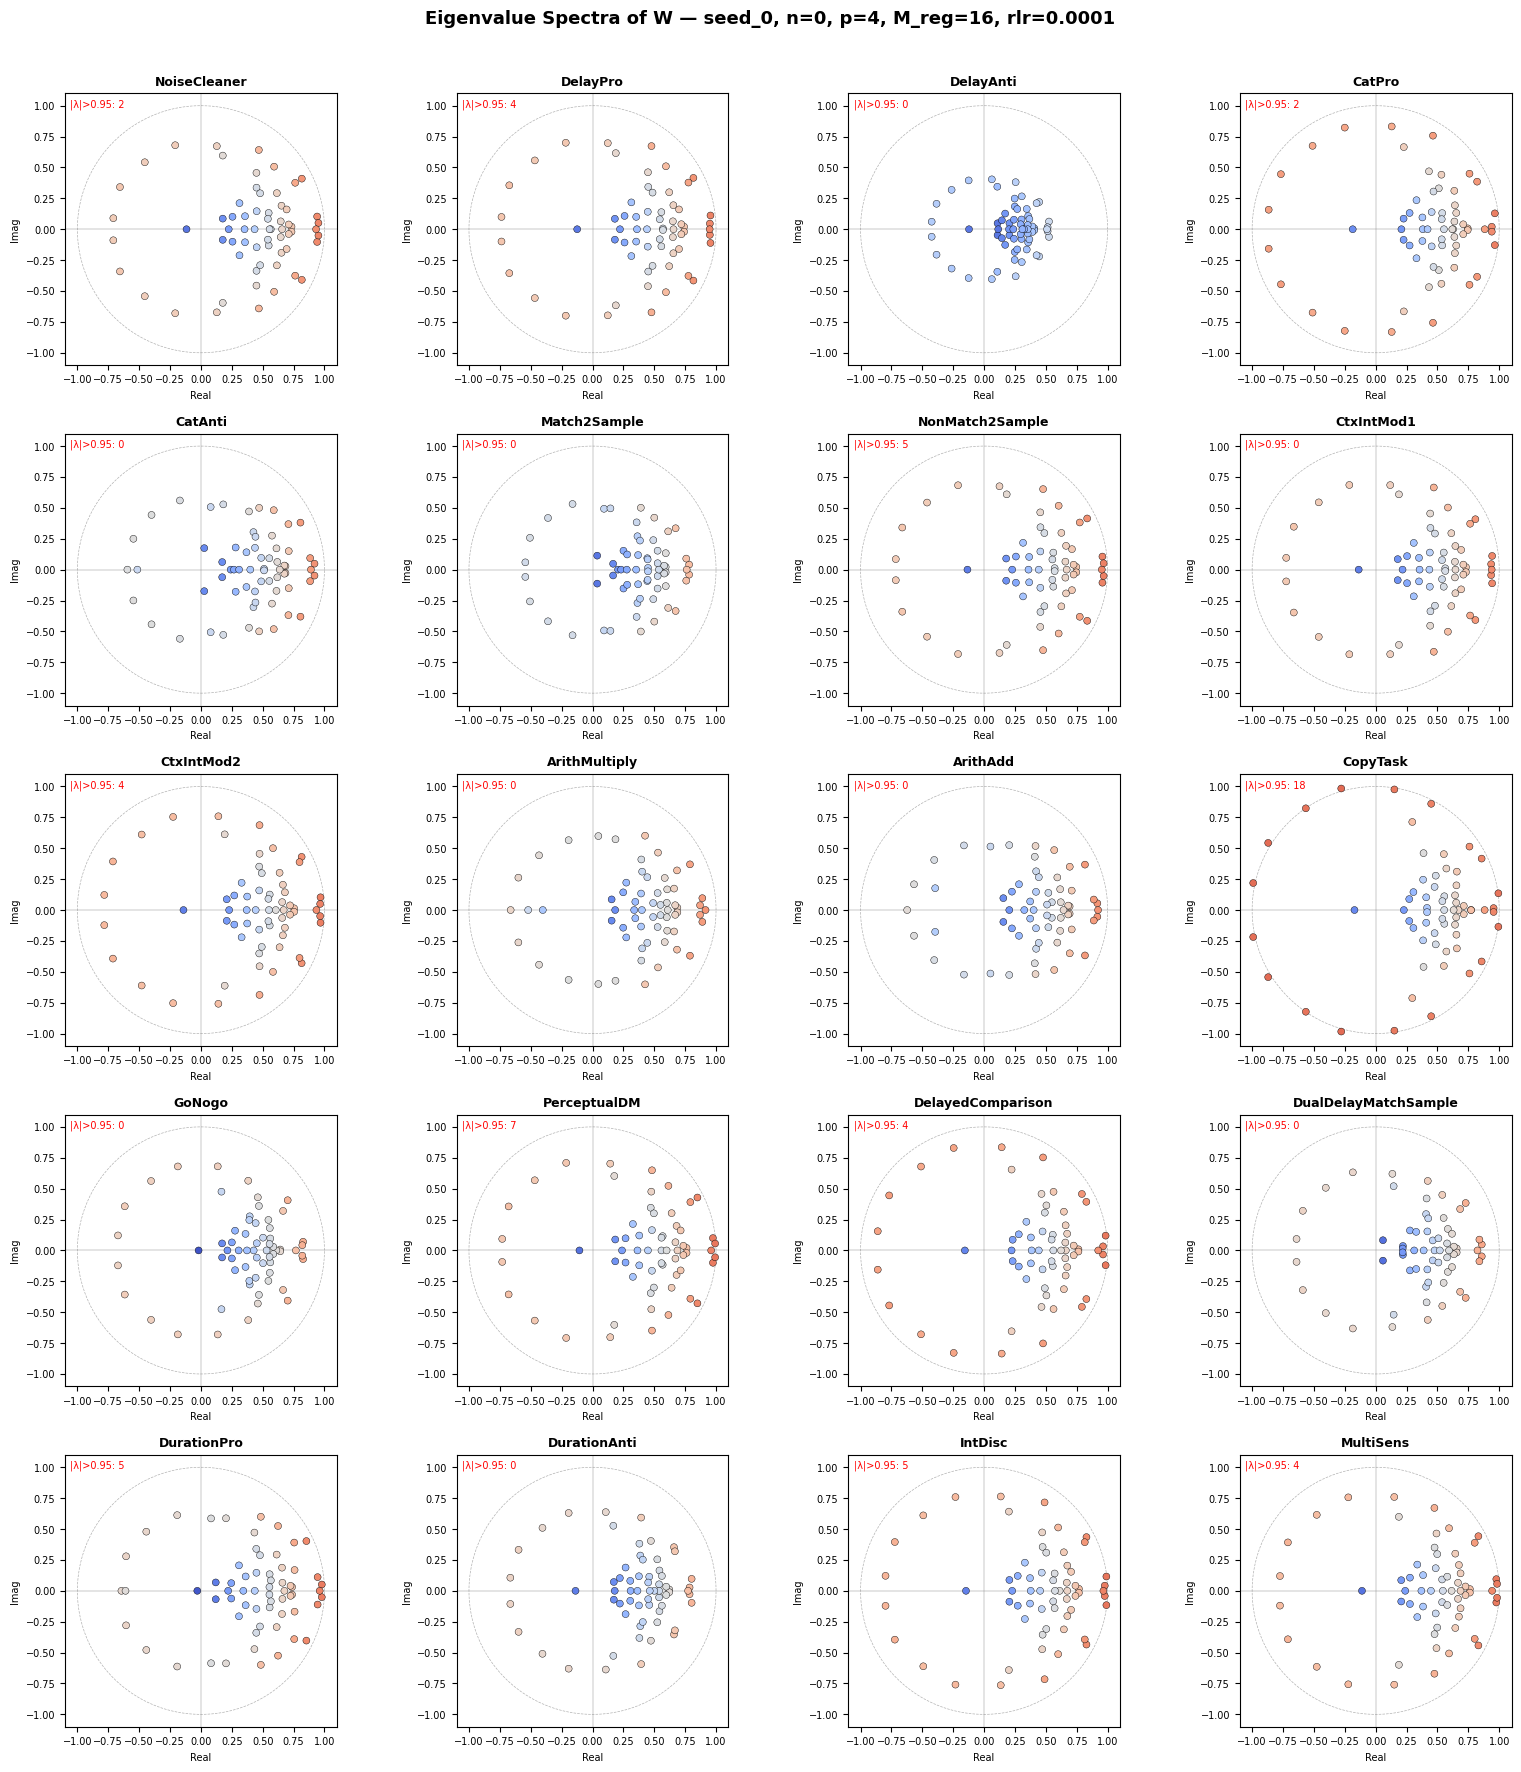

In [37]:
# --- Eigenvalue spectra in the complex plane — one plot per task ---

ncols = 4
nrows = (n_tasks + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.5 * nrows))
axes = axes.flatten()

for idx, task in enumerate(task_names):
    ax = axes[idx]
    eigvals = np.linalg.eigvals(W_per_task[idx])

    # Unit circle
    theta = np.linspace(0, 2 * np.pi, 200)
    ax.plot(np.cos(theta), np.sin(theta), 'k--', linewidth=0.5, alpha=0.3)

    # Color by magnitude
    mags = np.abs(eigvals)
    sc = ax.scatter(eigvals.real, eigvals.imag, c=mags, cmap='coolwarm',
                    s=25, edgecolors='black', linewidth=0.3, vmin=0, vmax=1.2, zorder=3)

    ax.axhline(0, color='gray', linewidth=0.3)
    ax.axvline(0, color='gray', linewidth=0.3)
    ax.set_aspect('equal')
    ax.set_title(task, fontsize=9, fontweight='bold')
    ax.tick_params(labelsize=7)
    ax.set_xlabel('Real', fontsize=7)
    ax.set_ylabel('Imag', fontsize=7)

    # Annotate: count eigenvalues with |lambda| > 0.95
    n_persistent = np.sum(mags > 0.95)
    ax.text(0.02, 0.98, f'|λ|>0.95: {n_persistent}', transform=ax.transAxes,
            fontsize=7, va='top', color='red')

for i in range(n_tasks, len(axes)):
    axes[i].set_visible(False)

fig.suptitle('Eigenvalue Spectra of W — seed_0, n=0, p=4, M_reg=16, rlr=0.0001',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

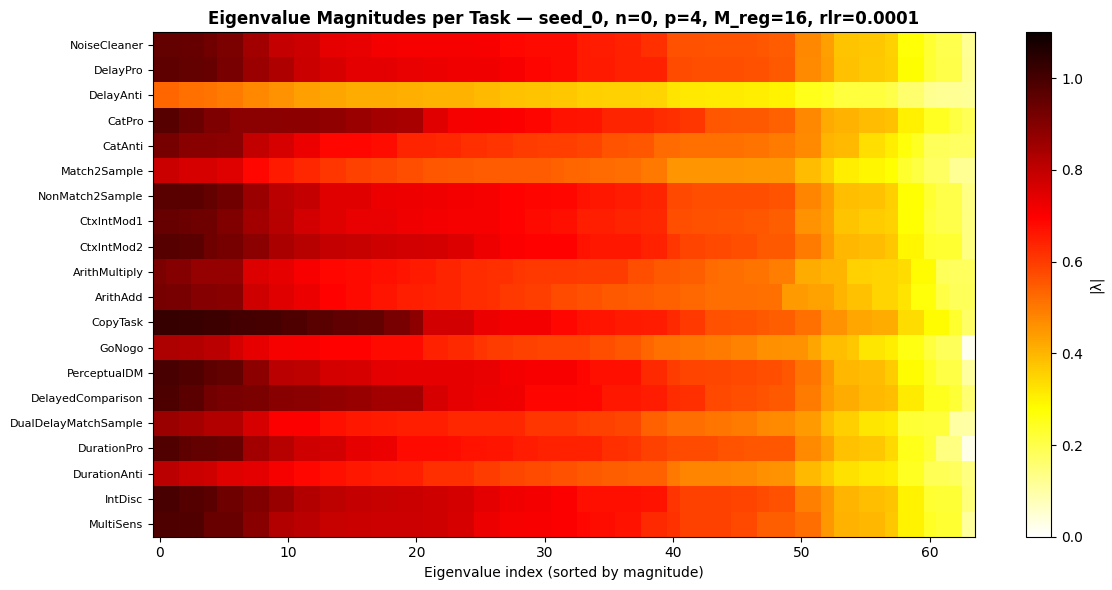


Effective dimensionality (|λ| > 0.95):
  NoiseCleaner: 2
  DelayPro: 4
  DelayAnti: 0
  CatPro: 2
  CatAnti: 0
  Match2Sample: 0
  NonMatch2Sample: 5
  CtxIntMod1: 0
  CtxIntMod2: 4
  ArithMultiply: 0
  ArithAdd: 0
  CopyTask: 18
  GoNogo: 0
  PerceptualDM: 7
  DelayedComparison: 4
  DualDelayMatchSample: 0
  DurationPro: 5
  DurationAnti: 0
  IntDisc: 5
  MultiSens: 4


In [38]:
# --- Heatmap: sorted eigenvalue magnitudes per task ---
all_mags = []
for idx in range(n_tasks):
    eigvals = np.linalg.eigvals(W_per_task[idx])
    mags = np.sort(np.abs(eigvals))[::-1]  # sorted descending
    all_mags.append(mags)

all_mags = np.array(all_mags)  # (n_tasks, M)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(all_mags, aspect='auto', cmap='hot_r', vmin=0, vmax=1.1)
ax.set_yticks(range(n_tasks))
ax.set_yticklabels(task_names, fontsize=8)
ax.set_xlabel('Eigenvalue index (sorted by magnitude)', fontsize=10)
ax.set_title('Eigenvalue Magnitudes per Task — seed_0, n=0, p=4, M_reg=16, rlr=0.0001',
             fontsize=12, fontweight='bold')
plt.colorbar(im, ax=ax, label='|λ|')
plt.tight_layout()
plt.show()

# Print effective dimensionality (number of eigenvalues > 0.95)
print("\nEffective dimensionality (|λ| > 0.95):")
for idx, task in enumerate(task_names):
    n_eff = np.sum(all_mags[idx] > 0.95)
    print(f"  {task}: {n_eff}")

NameError: name 'nl' is not defined

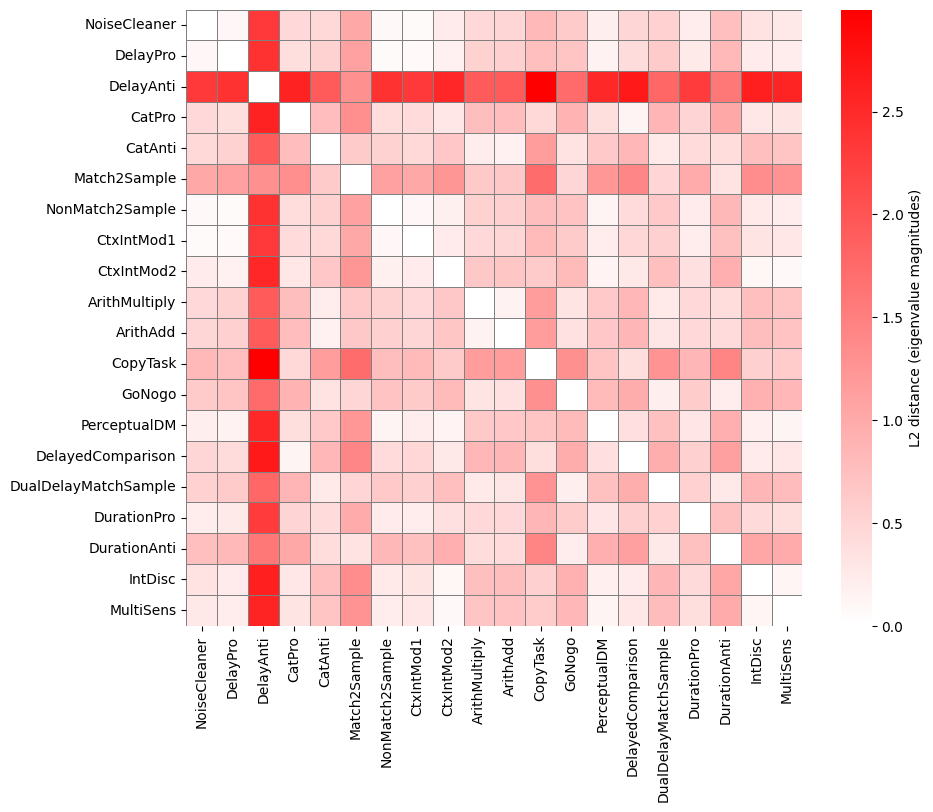

In [39]:
from scipy.spatial.distance import pdist, squareform
from matplotlib.colors import LinearSegmentedColormap

# Task similarity: L2 distance between sorted eigenvalue magnitude vectors
dist_matrix = squareform(pdist(all_mags, metric='euclidean'))

# Red (low distance = similar) to white (high distance = dissimilar)
cmap_rw = LinearSegmentedColormap.from_list('red_white', [ 'white', 'red'])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(dist_matrix, xticklabels=task_names, yticklabels=task_names,
            cmap=cmap_rw, ax=ax,
            linewidths=0.5, linecolor='gray', square=True,
            cbar_kws={'label': 'L2 distance (eigenvalue magnitudes)'})
ax.set_title(f'Task Similarity (Eigenvalue Spectra)\u2014 nl={nl}, p={num_params}, seed={seed}',
             fontsize=12, fontweight='bold')
ax.tick_params(labelsize=8)
plt.tight_layout()
plt.show()